# `py4conjoint` — 混在水準デモ

このノートブックは `py4conjoint` の **属性間で水準数が異なるケース** を合成データで動作確認するためのものです。

---

**設計シナリオ：スマートフォン選択コンジョイント分析（3属性・混在水準）**

| 属性 | 水準数 | 水準 | 基準水準 |
|:------:|:----:|------|:------:|
| price（万円） | **3** | 6・8・10 | 10 |
| os | 2 | android・apple | android |
| camera | **3** | 標準・高性能・超高性能 | 標準 |

---

| セクション | 内容 |
|:---:|------|
| 0 | セットアップ |
| 1 | プロファイル設計と `pc.check_design()` |
| 2 | 合成データの作成 |
| 3 | `pc.encode()` — 混在水準の効果コーディング |
| 4 | `pc.fit()` — OLS 回帰 |
| 5 | `ConjointResult` のフィールド |
| 6 | `result.warnings()` |
| 7 | `result.importance()` |
| 8 | `result.unit_rating_money()` |
| 9 | `result.wtp()` |
| 10 | `result.market_share()` |
| 11 | 可視化 |

## 0. セットアップ

In [1]:
import numpy as np
import pandas as pd
import py4conjoint as pc

print(f"py4conjoint version: {pc.__version__}")

py4conjoint version: 0.3.0


## 1. プロファイル設計と `pc.check_design()` — アンケート前の直交性診断

アンケートを実施する前に、プロファイルの設計が **直交性・バランス** の条件を満たしているかを診断します。

### プロファイル設計（12プロファイル）

今回は **price（3水準）× os（2水準）× camera（3水準）** の混在設計です。  

### 1-A. `pc.suggest_n_profiles()` — n_profiles の値をどう決めるか

`design_profiles()` の ``n_profiles`` に何を設定すればよいか迷ったときの補助関数。
属性数・水準数・予定回答者数から **推奨プロファイル数** を計算して返す。

**n_profiles を決める 3 つの基準**

| 基準 | 式 | 説明 |
|------|----|------|
| 統計的最低限 | M ≥ p | 回帰が実行できる絶対最小値。p = 切片 + Σ(水準数 - 1) |
| Orme の経験則 | M ≈ 符号化列数 × 2 | 推定が実用的に安定する目安（実務慣行） |
| 観測数条件 | M × 回答者数 ≥ 10 × 符号化列数 | `fit()` が中警告を出さない水準 |

推奨値 = 3 基準の最大値 を `min(N, max_burden)` で上限制限。

In [2]:
# 属性と水準の辞書（完全交差 = 3×2×3 = 18 通り）
attribute_levels = {
    "price":  [6, 8, 10],
    "os":     ["android", "apple"],
    "camera": ["標準", "高性能", "超高性能"],
}

In [3]:
# 回答者数ごとの推奨プロファイル数一覧
guide = pc.suggest_n_profiles(attribute_levels)

print(f"パラメータ数 p   = {guide.attrs['n_params']}（切片 1 + 符号化列 {guide.attrs['n_encoded']}）")
print(f"完全交差 N       = {guide.attrs['n_candidates']} 通り  (= 3×2×3)")
print(f"統計的最低限 M   = {guide.attrs['m_min']} (= p)")
print(f"Orme の目安 M   ≈ {guide.attrs['m_orme']} (= 符号化列数 × 2)")
print()
guide

パラメータ数 p   = 6（切片 1 + 符号化列 5）
完全交差 N       = 18 通り  (= 3×2×3)
統計的最低限 M   = 6 (= p)
Orme の目安 M   ≈ 10 (= 符号化列数 × 2)



,回答者数,obs/pred≥10（最低限）,推奨 n_profiles,obs/pred（達成）,観測数 obs
0,5,10,10,10.0,50
1,10,6,10,20.0,100
2,20,6,10,40.0,200
3,30,6,10,60.0,300
4,50,6,10,100.0,500
5,100,6,10,200.0,1000


In [4]:
# このノートブックの設定（回答者 25 名）に対する推奨値
guide_25 = pc.suggest_n_profiles(attribute_levels, n_respondents=25)
print(guide_25.to_string(index=False))
print()
rec = int(guide_25["推奨 n_profiles"].iloc[0])
print(f"→ 推奨 n_profiles = {rec}")
print(f"\n以下では n_profiles=12 で設計しており、推奨範囲内です。")

 回答者数  obs/pred≥10（最低限）  推奨 n_profiles  obs/pred（達成）  観測数 obs
   25                 6             10          50.0      250

→ 推奨 n_profiles = 10

以下では n_profiles=12 で設計しており、推奨範囲内です。


### 1-B. `pc.design_profiles()` — D 最適計画で N 通りから M 個を自動選択

アンケートで使うプロファイルを手動で決める代わりに、
`design_profiles()` を使うと **D 最適計画法（Fedorov 交換アルゴリズム）** で
全 N = ∏(水準数) 通りの候補から自動的に最適な M 個を選べます。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `attribute_levels` | dict | — | `{"属性名": [水準1, ...]}` の辞書 |
| `n_profiles` | int | — | 選択するプロファイル数 M |
| `reference_levels` | dict | `None` | 効果コーディングの基準水準（`encode()` と合わせる） |
| `n_starts` | int | `10` | 試行回数（多いほど良い解を見つけやすい） |
| `seed` | int | `None` | 乱数シード（再現性のため） |

返り値の `df.attrs` に設計品質指標が保存される：

| キー | 内容 |
|------|------|
| `d_efficiency` | D 相対効率（0〜1）。完全交差を全件選んだ場合のみ 1.0 |
| `n_candidates` | 完全交差の候補数 N |
| `det_xpx` | 選択設計の det(X'X) |

In [5]:
# D 最適計画：18 通りから 12 プロファイルを自動選択
profiles = pc.design_profiles(
    attribute_levels,
    n_profiles=12,
    reference_levels={"price": 10, "os": "android", "camera": "標準"},
    n_starts=20,
    seed=42,
)

print(f"候補数 N       = {profiles.attrs['n_candidates']}（= 3×2×3 の完全交差）")
print(f"D 相対効率     = {profiles.attrs['d_efficiency']:.4f}  ← 1.0 に近いほど良い設計")
print(f"det(X\'X)       = {profiles.attrs['det_xpx']:.2f}")
profiles

候補数 N       = 18（= 3×2×3 の完全交差）
D 相対効率     = 0.6525  ← 1.0 に近いほど良い設計
det(X'X)       = 291600.00


,price,os,camera
P1,6,android,標準
P2,6,android,高性能
P3,6,apple,高性能
P4,6,apple,超高性能
P5,8,android,標準
P6,8,android,超高性能
P7,8,apple,標準
P8,8,apple,高性能
P9,10,android,高性能
P10,10,android,超高性能


**D 相対効率の読み方**

$$
\text{D-efficiency} = \left(\frac{\det(X_{\text{sel}}'X_{\text{sel}})}{\det(X_{\text{full}}'X_{\text{full}})}\right)^{1/p}
$$

- $p$：パラメータ数（切片含む）
- 完全交差 N 件をすべて選んだ場合のみ 1.0 になる
- 同じ `n_profiles` の中では、値が大きいほど情報量が多い（D 最適な）設計

**ランダム選択との比較**（参考）

In [6]:
import itertools

rng_c = np.random.default_rng(0)
# ランダムに 12 個を選んだ場合の d_efficiency を 100 回計算して分布を確認
from py4conjoint.design import _build_effect_matrix

ref_lvls = {"price": 10, "os": "android", "camera": "標準"}
full_df = pd.DataFrame(
    [dict(zip(attribute_levels.keys(), c))
     for c in itertools.product(*attribute_levels.values())]
)
X_full = _build_effect_matrix(full_df, attribute_levels, ref_lvls)
det_full = float(np.linalg.det(X_full.T @ X_full))
p = X_full.shape[1]
N = len(full_df)

rand_effs = []
for _ in range(200):
    idx = rng_c.choice(N, 12, replace=False)
    X_r = X_full[idx]
    det_r = float(np.linalg.det(X_r.T @ X_r))
    rand_effs.append((det_r / det_full) ** (1.0 / p) if det_full > 0 and det_r > 0 else 0.0)

print(f"D 最適設計の d_efficiency  = {profiles.attrs['d_efficiency']:.4f}")
print(f"ランダム選択の中央値        = {float(np.median(rand_effs)):.4f}")
print(f"ランダム選択の最大値        = {max(rand_effs):.4f}")
print(f"ランダム選択の最小値        = {min(rand_effs):.4f}")

D 最適設計の d_efficiency  = 0.6525
ランダム選択の中央値        = 0.6090
ランダム選択の最大値        = 0.6460
ランダム選択の最小値        = 0.5537


In [7]:
# 参考：手動設計（design_profiles() との比較用）
profiles_manual = pd.DataFrame(
    {
        "price":  [ 6,  6,  6,  6,  8,  8,  8,  8, 10, 10, 10, 10],
        "os":     ["android","apple","android","apple",
                   "android","apple","android","apple",
                   "android","apple","android","apple"],
        "camera": ["標準","高性能","超高性能","標準",
                   "高性能","超高性能","標準","高性能",
                   "超高性能","標準","高性能","超高性能"],
    },
    index=[f"P{i}" for i in range(1, 13)],
)
profiles_manual
profiles

,price,os,camera
P1,6,android,標準
P2,6,android,高性能
P3,6,apple,高性能
P4,6,apple,超高性能
P5,8,android,標準
P6,8,android,超高性能
P7,8,apple,標準
P8,8,apple,高性能
P9,10,android,高性能
P10,10,android,超高性能


### `pc.check_design()` — 直交性チェック

`check_design()` は `fit()` の前に呼ぶ独立した関数です。scipy 不要（numpy・pandas のみ）で動作します。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `profiles` | DataFrame | — | 属性と水準を持つプロファイルのDataFrame |
| `attributes` | list of str | `None` | チェック対象の属性名（省略時は全列） |

**返り値**: `DesignCheckResult`（`balance`・`correlation`・`chi2`・`diagnostics` を持つ）

**評価記号**

| 記号 | 意味 |
|:---:|------|
| ◎ | 優良（CV < 0.05 / χ²/自由度 < 0.1） |
| ○ | 良好（CV < 0.15 / χ²/自由度 < 1.0） |
| △ | 要確認（それ以外） |

In [8]:
design_check = pc.check_design(profiles)
print(design_check)

デザイン直交性チェック

【水準バランス】（CV が小さいほど均等）
  属性  水準数  最大出現  最小出現   CV  評価
 price       3         4         4  0.0     ◎
    os       2         6         6  0.0     ◎
camera       3         4         4  0.0     ◎

【属性間相関】（0 に近いほど直交）
           price__0  price__1   os  camera__0  camera__1
price__0      1.000     0.500 -0.0     -0.250     -0.125
price__1      0.500     1.000  0.0     -0.125      0.125
os           -0.000     0.000  1.0     -0.000     -0.000
camera__0    -0.250    -0.125 -0.0      1.000      0.500
camera__1    -0.125     0.125 -0.0      0.500      1.000

【独立性（χ²統計量）】（自由度に対して小さいほど独立）
属性1   属性2   χ²  自由度  χ²/自由度  評価
price      os  0.0       2        0.0     ◎
price  camera  1.5       4      0.375     ○
   os  camera  0.0       2        0.0     ◎

警告はありません。


In [9]:
# 各チェック結果を個別に確認
print("【水準バランス】")
print(design_check.balance)

print("\n【属性間相関】")
print(design_check.correlation)

print("\n【独立性（χ²統計量）】")
print(design_check.chi2)

print("\n【警告一覧】")
print(design_check.warnings())

【水準バランス】
        水準数  最大出現  最小出現   CV 評価
属性                             
price     3     4     4  0.0  ◎
os        2     6     6  0.0  ◎
camera    3     4     4  0.0  ◎

【属性間相関】
           price__0  price__1   os  camera__0  camera__1
price__0      1.000     0.500 -0.0     -0.250     -0.125
price__1      0.500     1.000  0.0     -0.125      0.125
os           -0.000     0.000  1.0     -0.000     -0.000
camera__0    -0.250    -0.125 -0.0      1.000      0.500
camera__1    -0.125     0.125 -0.0      0.500      1.000

【独立性（χ²統計量）】
     属性1     属性2   χ²  自由度  χ²/自由度 評価
0  price      os  0.0    2   0.000  ◎
1  price  camera  1.5    4   0.375  ○
2     os  camera  0.0    2   0.000  ◎

【警告一覧】
Empty DataFrame
Columns: [severity, category, message, recommendation]
Index: []


**ポイント**
- `price × os`・`os × camera` のχ²は 0 → 完全独立 ◎
- `price × camera` のχ²/自由度 ≈ 0.375 → 軽微な非独立性 ○（許容範囲）
- 3水準属性（`price__0`/`price__1`、`camera__0`/`camera__1`）の同一属性内ペアは相関チェックから除外されます
- 警告が出ない場合は設計品質が良好です

## 2. 合成データの作成

実際のアンケート回答を模した **合成データ** を生成します。  
25名の回答者が 12 プロファイルをすべて評価（1〜7点）するケースを想定します。

**真の効用（真値として埋め込む）**

| 属性 | 水準 | 真の部分効用 |
|------|------|:----------:|
| 切片 | — | 4.0 |
| price | 6万円 | +2.0 |
| price | 8万円 | 0.0 |
| price | 10万円（基準） | −2.0（推定値） |
| os | apple | +1.0 |
| os | android（基準） | −1.0（推定値） |
| camera | 高性能 | +0.5 |
| camera | 超高性能 | +1.0 |
| camera | 標準（基準） | −1.5（推定値） |

In [10]:
# ---- 真の効用パラメータ ----
TRUE_INTERCEPT = 4.0
TRUE_UTILITY = {
    "price":  {6: 2.0, 8: 0.0, 10: -2.0},
    "os":     {"android": -1.0, "apple":  1.0},
    "camera": {"標準": -1.5, "高性能": 0.5, "超高性能": 1.0},
}
NOISE_SD = 0.6
N_RESP   = 25

rng = np.random.default_rng(42)
rows = []
for r in range(1, N_RESP + 1):
    for pid, prof in profiles.iterrows():
        u = TRUE_INTERCEPT
        for attr, utils in TRUE_UTILITY.items():
            u += utils[prof[attr]]
        u += rng.normal(0, NOISE_SD)
        rating = int(np.clip(round(u), 1, 7))
        rows.append({
            "回答者ID": r, "プロファイルID": pid, "rating": rating,
            **prof.to_dict(),
        })

df = pd.DataFrame(rows)
print(f"観測数: {len(df)}（{N_RESP}人 × {len(profiles)}プロファイル）")
df.head(12)

観測数: 300（25人 × 12プロファイル）


,回答者ID,プロファイルID,rating,price,os,camera
0,1,P1,4,6,android,標準
1,1,P2,5,6,android,高性能
2,1,P3,7,6,apple,高性能
3,1,P4,7,6,apple,超高性能
4,1,P5,1,8,android,標準
5,1,P6,3,8,android,超高性能
6,1,P7,4,8,apple,標準
7,1,P8,5,8,apple,高性能
8,1,P9,1,10,android,高性能
9,1,P10,1,10,android,超高性能


## 3. `pc.encode()` — 混在水準の効果コーディング（-1 / 0 / +1）

属性列を **効果コーディング** に自動変換します。

**水準数に応じた列名の規則**

| 水準数 | 生成列数 | `suffix_map` 指定なし | `suffix_map` 指定あり |
|:------:|:------:|----------------------|----------------------|
| 2水準 | K-1 = 1 | `{属性名}_0` | `{属性名}_{指定サフィックス}` |
| 3水準 | K-1 = 2 | `{属性名}_0`, `{属性名}_1` | `{属性名}_{サフィックス[0]}`, `{属性名}_{サフィックス[1]}` |

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `df` | DataFrame | — | long 形式のデータ |
| `reference_levels` | dict | — | `{"属性名": 基準水準}` の辞書。基準水準が `-1` になる |
| `suffix_map` | dict | `None` | 列名サフィックスを手動指定。2水準は `str`、3水準以上は `List[str]`（非基準水準と同じ数・同じ順） |
| `drop_original` | bool | `False` | 元の属性列を削除するか |
| `inplace` | bool | `False` | 入力 df を直接書き換えるか |

In [11]:
df_coded = pc.encode(
    df,
    reference_levels={
        "price":  10,        # 高い方を基準（評点が低くなりそう）
        "os":     "android",
        "camera": "標準",
    },
    suffix_map={
        "price":  ["low", "mid"],    # 3水準 → price_low（6万円）, price_mid（8万円）
        "camera": ["high", "ultra"], # 3水準 → camera_high（高性能）, camera_ultra（超高性能）
        # os は 2水準なので suffix_map を省略 → os_0（apple）になる
    },
)

# 生成された符号化列の確認
enc_cols = [c for c in df_coded.columns
            if c not in ["回答者ID", "プロファイルID", "rating", "price", "os", "camera"]]
print(f"符号化列: {enc_cols}")
print()
df_coded[["rating", "price", "os", "camera"] + enc_cols].head(12)

符号化列: ['price_low', 'price_mid', 'os_0', 'camera_high', 'camera_ultra']



,rating,price,os,camera,price_low,price_mid,os_0,camera_high,camera_ultra
0,4,6,android,標準,1,0,-1,-1,-1
1,5,6,android,高性能,1,0,-1,1,0
2,7,6,apple,高性能,1,0,1,1,0
3,7,6,apple,超高性能,1,0,1,0,1
4,1,8,android,標準,0,1,-1,-1,-1
5,3,8,android,超高性能,0,1,-1,0,1
6,4,8,apple,標準,0,1,1,-1,-1
7,5,8,apple,高性能,0,1,1,1,0
8,1,10,android,高性能,-1,-1,-1,1,0
9,1,10,android,超高性能,-1,-1,-1,0,1


In [12]:
# 効果コーディングの値の確認
print("【price の効果コーディング】")
print(df_coded.groupby("price")[["price_low", "price_mid"]].first())

print("\n【camera の効果コーディング】")
print(df_coded.groupby("camera")[["camera_high", "camera_ultra"]].first())

print("\n【os の効果コーディング】")
print(df_coded.groupby("os")[["os_0"]].first())

【price の効果コーディング】
       price_low  price_mid
price                      
6              1          0
8              0          1
10            -1         -1

【camera の効果コーディング】
        camera_high  camera_ultra
camera                           
標準               -1            -1
超高性能              0             1
高性能               1             0

【os の効果コーディング】
         os_0
os           
android    -1
apple       1


**効果コーディングの読み方（3水準の場合）**

| price | price_low | price_mid | 解釈 |
|:-----:|:---------:|:---------:|------|
| 6万円（非基準①） | +1 | 0 | price_low 列だけ +1 |
| 8万円（非基準②） | 0 | +1 | price_mid 列だけ +1 |
| 10万円（基準） | −1 | −1 | すべての K-1 列が −1 |

この「基準水準 = すべての符号化列が -1」という規則が効果コーディングの特徴です。

## 4. `pc.fit()` — OLS 回帰

符号化済み DataFrame に OLS 回帰を適用し、`ConjointResult` を返します。  
欠損値の除外・日本語列名の自動エイリアス処理・落とし穴チェックを自動実行します。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `df` | DataFrame | — | `encode()` 済みのデータ |
| `rating` | str | `"rating"` | 評点（被説明変数）の列名 |
| `price_col` | str | `"price"` | 価格列名。WTP 計算で使用 |
| `encoded_columns` | list of str | `None` | 説明変数リスト（省略時は自動検出） |
| `reference_levels` | dict | `None` | 基準水準辞書（`encode()` 経由なら自動取得） |
| `formula` | str | `None` | statsmodels 用の回帰式を直接指定 |
| `respondent_id_col` | str | `"回答者ID"` | 回答者ID列名（クラスタロバスト標準誤差と回答者数診断に使用） |
| `cluster_se` | bool | `True` | 回答者IDによるクラスタロバスト標準誤差を使用（係数は不変、p値が適正化） |

**返り値**: `ConjointResult` オブジェクト

In [13]:
result = pc.fit(df_coded, price_col="price")
result

============================================================
コンジョイント分析の結果（和文サマリー）
============================================================
観測数        : 300
説明変数の数  : 5
決定係数 R²   : 0.9121
自由度修正 R² : 0.9106
標準誤差      : クラスタロバスト（回答者ID）

【推定された係数（部分効用 part-worth）】
  変数                            係数        p値  有意性
  ------------------------- ---------- ----------  ------
  Intercept                     3.8633     0.0000  ***
  price_low                     1.6747     0.0000  ***
  price_mid                     0.1093     0.0783  .
  os_0                          0.9100     0.0000  ***
  camera_high                   0.5280     0.0000  ***
  camera_ultra                  0.8027     0.0000  ***

  有意水準: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1
============================================================

**推定結果の解釈**

- `price_low`（price=6万円）の係数 ≈ +2.0 → 安い価格は評点を上げる
- `price_mid`（price=8万円）の係数 ≈ 0.0 → 中間価格は効用に影響しない
- `os_0`（apple）の係数 ≈ +1.0 → apple は評点を上げる
- `camera_high`（高性能）の係数 ≈ +0.5 → 高性能カメラはやや評点を上げる
- `camera_ultra`（超高性能）の係数 ≈ +1.0 → 超高性能カメラは評点を大きく上げる

## 5. `ConjointResult` のフィールド

### 5-A. プロパティ

| プロパティ | 型 | 説明 |
|-----------|----|------|
| `params` | `pd.Series` | 推定係数（切片含む） |
| `rsquared` | `float` | 決定係数 R² |
| `n_obs` | `int` | 分析に使用した観測数 |
| `intercept` | `float` | 切片 b₀（全水準平均の効用） |

In [14]:
print("result.params")
print(result.params)
print()
print(f"result.rsquared  = {result.rsquared:.4f}")
print(f"result.n_obs     = {result.n_obs}")
print(f"result.intercept = {result.intercept:.4f}")

result.params
Intercept       3.863333
price_low       1.674667
price_mid       0.109333
os_0            0.910000
camera_high     0.528000
camera_ultra    0.802667
dtype: float64

result.rsquared  = 0.9121
result.n_obs     = 300
result.intercept = 3.8633


### 5-B. データフィールド

| フィールド | 型 | 説明 |
|-----------|----|------|
| `rating` | `str` | 評点列名 |
| `encoded_columns` | `list` | 説明変数（符号化列）のリスト |
| `reference_levels` | `dict` | 基準水準辞書 |
| `price_col` | `str` | 価格列名 |
| `n_dropped` | `int` | 欠損除外された行数 |
| `ols` | `RegressionResults` | statsmodels の生の推定結果 |

In [15]:
print(f"result.encoded_columns  = {result.encoded_columns}")
print(f"result.reference_levels = {result.reference_levels}")
print(f"result.price_col        = {result.price_col!r}")
print(f"result.n_dropped        = {result.n_dropped}")

result.encoded_columns  = ['price_low', 'price_mid', 'os_0', 'camera_high', 'camera_ultra']
result.reference_levels = {'price': 10, 'os': 'android', 'camera': '標準'}
result.price_col        = 'price'
result.n_dropped        = 0


In [16]:
# statsmodels の詳細表示
print(result.summary(slim=False))

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     1675.
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           1.07e-29
Time:                        21:42:22   Log-Likelihood:                -267.27
No. Observations:                 300   AIC:                             546.5
Df Residuals:                     294   BIC:                             568.8
Df Model:                           5                                         
Covariance Type:              cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.8633      0.036    107.482   

## 6. `result.warnings()` — 落とし穴チェック

回帰分析で自動検出された診断警告の一覧を返します。

**自動検出される警告の種類**

| カテゴリ | 重大度 | 検出タイミング | 内容 |
|----------|:------:|:-----------:|------|
| `r2_low` | 大 | `fit()` 直後 | R² < 0.20 |
| `obs_per_predictor` | 大/中 | `fit()` 直後 | 観測数／説明変数数の比率が低い |
| `few_respondents` | 大/中 | `fit()` 直後 | 回答者数が少ない |
| `independence_assumed` | 中 | `fit()` 直後 | 回答者ID列が無く、観測の独立性を仮定した標準誤差を使用（p値が過小になる恐れ） |
| `price_sign_negative` | 中 | `fit()` 直後 | 価格係数の符号が逆かつ有意 |
| `price_insignificant` | 中 | `wtp()` 呼出時 | 価格の p 値 ≥ 0.10（3水準以上は同時F検定） |
| `wtp_extrapolation` | 中 | `wtp()` 呼出時 | \|WTP\| > 価格レンジ × 2 |
| `wtp_price_linear_approx` | 中 | `wtp()` 呼出時 | **価格が3水準以上**のため線形近似を使用 |

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `severity` | str / list | `None` | 重大度でフィルタ（`"大"`/`"中"`/`"小"`） |
| `category` | str / list | `None` | カテゴリ名でフィルタ |
| `as_dataframe` | bool | `True` | `True` → DataFrame、`False` → `Diagnostic` リスト |

In [17]:
# wtp() を先に呼んで価格関連の警告も生成させる
_ = result.wtp()

# 全警告を確認
print("【全警告一覧】")
result.warnings()

【全警告一覧】


,severity,category,message,recommendation
0,中,wtp_price_linear_approx,価格が 3 水準あるため、価格効用が線形であると仮定してWTPを計算しています。,価格効用が等間隔でない場合は近似誤差が生じます。result.warnings() で詳細を...


In [18]:
# 重大度「大」のみ
print("【重大度 '大' のみ】")
print(result.warnings(severity="大"))

# カテゴリ指定
print("\n【wtp_price_linear_approx 警告の詳細】")
approx_w = result.warnings(category="wtp_price_linear_approx")
if len(approx_w) > 0:
    print(approx_w[["severity", "message", "recommendation"]].to_string())
else:
    print("警告なし")

【重大度 '大' のみ】
Empty DataFrame
Columns: [severity, category, message, recommendation]
Index: []

【wtp_price_linear_approx 警告の詳細】
  severity                                   message                                           recommendation
0        中  価格が 3 水準あるため、価格効用が線形であると仮定してWTPを計算しています。  価格効用が等間隔でない場合は近似誤差が生じます。result.warnings() で詳細を確認してください。


## 7. `result.importance()` — 重要度

各属性の **効用範囲（最大 − 最小）の比率** として重要度を計算します。

**計算式**
$$\text{importance}_i = \frac{\text{range}_i}{\sum_j \text{range}_j} \times 100$$

**水準数による効用範囲の計算**

| 水準数 | 計算式 |
|:------:|--------|
| 2水準 | `2 × |係数|` |
| 3水準以上 | `max(部分効用) − min(部分効用)`（基準水準 = `−Σ係数` で計算） |

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `as_percent` | bool | `True` | `True` → 合計 100%、`False` → 合計 1.0 の比率 |

In [19]:
imp = result.importance(as_percent=True)
print("【重要度（合計 100%）】")
print(imp)
print(f"  合計: {imp['重要度'].sum():.1f}%")

print()

# 効用範囲の内訳を手動で確認
print("【効用範囲の内訳（手動検算）】")
b_low   = result.params["price_low"]
b_mid   = result.params["price_mid"]
b_ref   = -(b_low + b_mid)          # 基準水準の効用
price_range = max(b_low, b_mid, b_ref) - min(b_low, b_mid, b_ref)

b_high  = result.params["camera_high"]
b_ultra = result.params["camera_ultra"]
b_std   = -(b_high + b_ultra)       # 基準水準の効用
camera_range = max(b_high, b_ultra, b_std) - min(b_high, b_ultra, b_std)

b_os = result.params["os_0"]
os_range = 2 * abs(b_os)            # 2水準: 2×|係数|

print(f"  price  の効用範囲: {price_range:.4f}  ({b_ref:.4f}, {b_mid:.4f}, {b_low:.4f})")
print(f"  os     の効用範囲: {os_range:.4f}  ({-b_os:.4f}, {b_os:.4f})")
print(f"  camera の効用範囲: {camera_range:.4f}  ({b_std:.4f}, {b_high:.4f}, {b_ultra:.4f})")

【重要度（合計 100%）】
            効用範囲        重要度
属性                         
price   3.458667  46.663069
os      1.820000  24.554776
camera  2.133333  28.782155
  合計: 100.0%

【効用範囲の内訳（手動検算）】
  price  の効用範囲: 3.4587  (-1.7840, 0.1093, 1.6747)
  os     の効用範囲: 1.8200  (-0.9100, 0.9100)
  camera の効用範囲: 2.1333  (-1.3307, 0.5280, 0.8027)


## 8. `result.unit_rating_money()` — 評点 1 点の金額換算

評点 1 ポイントが何円（または何万円）に相当するかを返します。

**計算式**

| 価格の水準数 | 計算式 |
|:-----------:|--------|
| 2水準 | `(price_max − price_min) / (\|b_price\| × 2)` |
| **3水準以上** | 価格水準と部分効用の線形近似スロープから算出（`wtp()` の仮定と同じ） |

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `price_col` | str | `None` | 価格列名（省略時は `fit()` の設定値） |

In [20]:
unit = result.unit_rating_money()
print(f"評点 1 点 = {unit:.4f} 万円")
print()
print("（3水準価格のため、価格効用の線形近似から算出）")
print(f"  = wtp_price_factor / 2 = {result.wtp().attrs['wtp_price_factor']:.4f} / 2 = {unit:.4f}")

評点 1 点 = 1.1565 万円

（3水準価格のため、価格効用の線形近似から算出）
  = wtp_price_factor / 2 = 2.3130 / 2 = 1.1565


## 9. `result.wtp()` — WTP（限界支払意思額）

各非価格属性の **WTP（Willingness to Pay）** を計算します。

> 基準水準から非基準水準に変えるとき、回答者が最大いくら追加で支払うか

**価格が 3 水準以上の場合の計算方法**

価格効用が線形であると仮定し、価格水準と部分効用を線形近似（`np.polyfit`）して  
「価格 1 単位あたりの効用変化（傾き）」を求めます。

$$\text{wtp\_price\_factor} = \frac{-2}{\text{slope}} \quad \text{（slope = polyfit による傾き < 0）}$$
$$\text{WTP}_k = \left(b_k + \sum\nolimits_j b_j\right) \times \frac{\text{wtp\_price\_factor}}{2}$$

（$\sum_j b_j$ は同じ属性の符号化列の係数和。2水準属性では $b_k + \sum_j b_j = 2b_k$ となり、従来の $\text{wtp\_price\_factor} \times b_k$ と同値）

この仮定が満たされない場合は近似誤差が生じるため、`wtp_price_linear_approx` 警告が自動で追加されます。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `price_col` | str | `None` | 価格列名（省略時は `fit()` の設定値） |

**返り値**: `pd.DataFrame`（インデックス: 符号化列名、列: `係数`, `限界支払意思額`）

In [21]:
wtp_df = result.wtp()
print("【WTP（限界支払意思額）】")
print(wtp_df)
print()
print("（価格が 3 水準あるため線形近似を使用。warnings() で詳細確認可能）")

【WTP（限界支払意思額）】
                    係数   限界支払意思額
属性（符号化列名）                       
os_0          0.910000  2.104857
camera_high   0.528000  2.149576
camera_ultra  0.802667  2.467232

（価格が 3 水準あるため線形近似を使用。warnings() で詳細確認可能）


In [22]:
# attrs に保存されたメタ情報
print(f"価格レンジ         : {wtp_df.attrs['price_range']:.1f} 万円")
print(f"wtp_price_factor   : {wtp_df.attrs['wtp_price_factor']:.4f}")
print(f"p_price（同時F検定）: {wtp_df.attrs['p_price']:.4f}")
print(f"最低価格 (low)     : {wtp_df.attrs['price_low']}")
print(f"最高価格 (high)    : {wtp_df.attrs['price_high']}")

価格レンジ         : 4.0 万円
wtp_price_factor   : 2.3130
p_price（同時F検定）: 0.0000
最低価格 (low)     : 6
最高価格 (high)    : 10


In [23]:
# 非価格属性が 3 水準（camera）の場合、K-1 = 2 行が出力される
print("WTP 出力行数:", len(wtp_df))
print("出力インデックス:", wtp_df.index.tolist())
print()
print("→ os_0（apple）・camera_high（高性能）・camera_ultra（超高性能）の 3 行")

WTP 出力行数: 3
出力インデックス: ['os_0', 'camera_high', 'camera_ultra']

→ os_0（apple）・camera_high（高性能）・camera_ultra（超高性能）の 3 行


## 10. `result.market_share()` — 市場シェア予測

複数製品の効用を推定し、市場シェアを予測します。

3 水準属性を含む製品の符号化値は次のルールに従います：

| 水準 | 符号化値（price_low / price_mid） |
|:---:|:---:|
| 6万円（非基準①） | price_low=1, price_mid=0 |
| 8万円（非基準②） | price_low=0, price_mid=1 |
| 10万円（基準） | price_low=−1, price_mid=−1 |

| 水準 | 符号化値（camera_high / camera_ultra） |
|:---:|:---:|
| 高性能（非基準①） | camera_high=1, camera_ultra=0 |
| 超高性能（非基準②） | camera_high=0, camera_ultra=1 |
| 標準（基準） | camera_high=−1, camera_ultra=−1 |

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `products` | DataFrame | — | 製品 × 符号化列の DataFrame |
| `method` | str | `"logit"` | `"logit"` / `"share_of_preference"` または `"max"` |

In [24]:
products = pd.DataFrame(
    {              #                  製品A     製品B     製品C
        "price_low":    [  1,   0,  -1],  # 6万円  8万円  10万円
        "price_mid":    [  0,   1,  -1],
        "os_0":         [  1,   1,  -1],  # apple  apple android
        "camera_high":  [  0,   1,  -1],  # 超高性能 高性能  標準
        "camera_ultra": [  1,   0,  -1],
    },
    index=["製品A（6万・apple・超高性能）",
           "製品B（8万・apple・高性能）",
           "製品C（10万・android・標準）"],
)

print('【method="logit"（デフォルト）】')
share_logit = result.market_share(products, method="logit")
print(share_logit.round(4))
print(f"  合計: {share_logit.sum():.6f}")

print()
print('【method="max"（最大効用ルール）】')
share_max = result.market_share(products, method="max")
print(share_max)

【method="logit"（デフォルト）】
製品A（6万・apple・超高性能）     0.8625
製品B（8万・apple・高性能）      0.1370
製品C（10万・android・標準）    0.0005
Name: market_share, dtype: float64
  合計: 1.000000

【method="max"（最大効用ルール）】
製品A（6万・apple・超高性能）     1.0
製品B（8万・apple・高性能）      0.0
製品C（10万・android・標準）    0.0
Name: market_share, dtype: float64


## 11. 可視化

3 つの可視化関数はいずれも **`result.plot_*()`** （ConjointResult メソッド）と
**`pc.plot_*()`**（モジュールレベル関数）の 2 通りで呼び出せます。

| 関数/メソッド | 主な引数 | 説明 |
|---|---|---|
| `plot_importance()` | `sort`, `show_values`, `color` | 重要度の水平棒グラフ |
| `plot_partworth()` | `show_zero_line` | 各水準の部分効用グラフ（属性ごとに色分け） |
| `plot_wtp()` | `sort`, `show_values`, `price_unit` | WTP の水平棒グラフ |

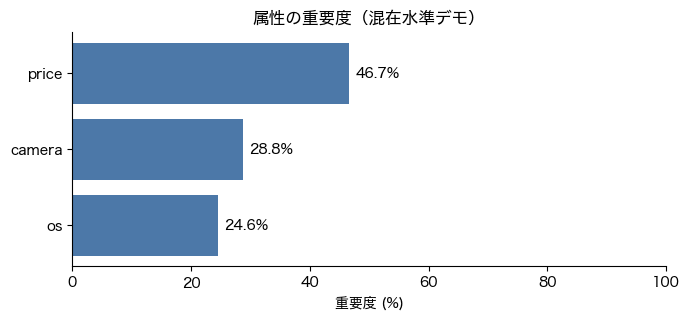

In [25]:
ax = result.plot_importance(
    title="属性の重要度（混在水準デモ）",
    show_values=True,
    sort=True,
)
ax.set_xlabel("重要度 (%)")
pass

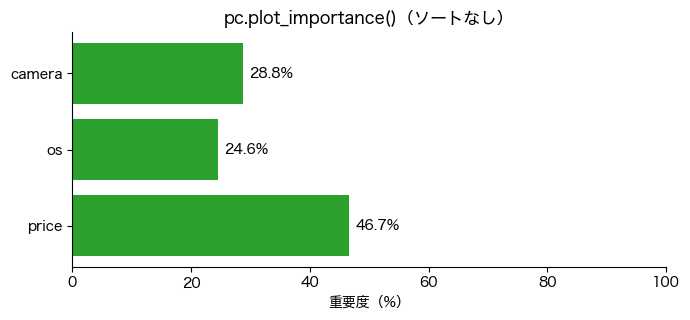

In [26]:
# pc モジュール関数として呼ぶ（同じ結果）
ax = pc.plot_importance(result, color="#2CA02C", sort=False)
ax.set_title("pc.plot_importance()（ソートなし）")
pass

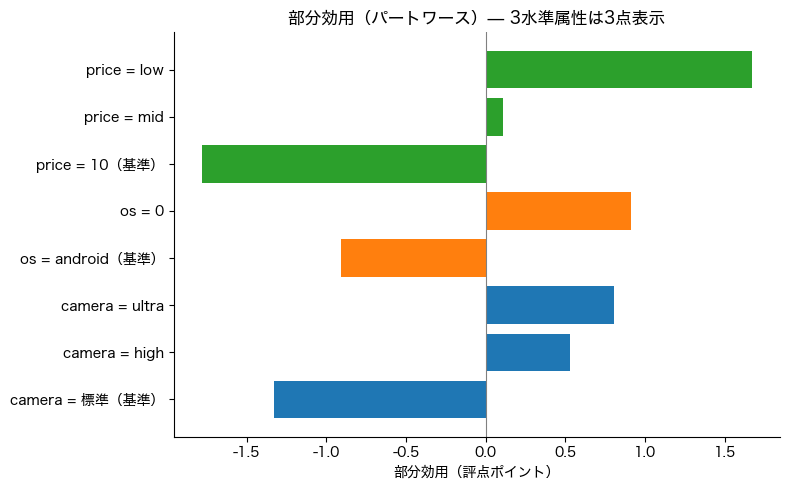

In [27]:
# 部分効用グラフ：3水準属性の3点が確認できる
ax = result.plot_partworth(
    title="部分効用（パートワース）— 3水準属性は3点表示",
    show_zero_line=True,
)
pass

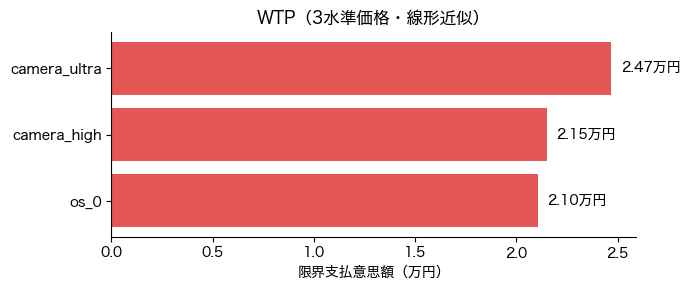

In [28]:
# WTP グラフ：camera は K-1 = 2 本の棒が表示される
ax = result.plot_wtp(
    price_unit="万円",
    show_values=True,
    sort=True,
    title="WTP（3水準価格・線形近似）",
)
pass

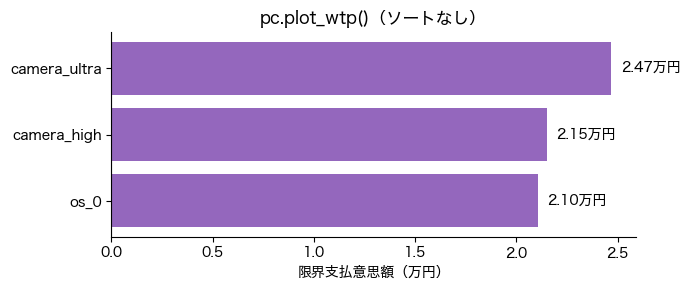

In [29]:
ax = pc.plot_wtp(result, price_unit="万円", color="#9467BD", sort=False)
ax.set_title("pc.plot_wtp()（ソートなし）")
pass